In [5]:
import pandas as pd
import optuna
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [6]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Augmented (Secondly) Dataset.csv')

# Drop diseases with less than 1000 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 1000].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 37
Number of rows left: 44748


In [7]:
# Optuna optimization function
def objective(trial):
    # Define the hyperparameters to tune for KNN
    n_neighbors = trial.suggest_int('n_neighbors', 3, 50)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_int('p', 1, 2)  # p=1 (Manhattan), p=2 (Euclidean)

    # Create KNeighborsClassifier with hyperparameters
    model = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p
    )

    # Perform cross-validation (using 5-fold by default)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    accuracy = score.mean()

    # Log the hyperparameters and accuracy for this trial
    print(f"Trial {trial.number}: n_neighbors={n_neighbors}, weights={weights}, p={p}, Accuracy={accuracy:.4f}")

    return accuracy

In [4]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize', 
    study_name="knn_diseases_symptoms_dropextremelymore1000withoutSMOTE_SecondAugmentation_study",
    storage=r"sqlite:///C:/Users/khiew/Downloads/knn.db", 
    load_if_exists=True
)

# Optimize the study with your objective function, adjust n_trials as needed
study.optimize(objective, n_trials=20)

# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

# After finding the best hyperparameters, you can fit the final KNN model on resampled data
best_params = study.best_trial.params
final_model = KNeighborsClassifier(
    n_neighbors=best_params['n_neighbors'],
    weights=best_params['weights'],
    p=best_params['p']
)
final_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")


[I 2025-04-30 12:31:00,717] Using an existing study with name 'knn_diseases_symptoms_dropextremelymore1000withoutSMOTE_SecondAugmentation_study' instead of creating a new one.


Trial 20: n_neighbors=30, weights=distance, p=1, Accuracy=0.8218


[I 2025-04-30 12:32:15,647] Trial 20 finished with value: 0.8218054821801054 and parameters: {'n_neighbors': 30, 'weights': 'distance', 'p': 1}. Best is trial 15 with value: 0.8235095137503208.
[I 2025-04-30 12:32:55,457] Trial 21 finished with value: 0.8237888550646488 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 2}. Best is trial 21 with value: 0.8237888550646488.


Trial 21: n_neighbors=16, weights=distance, p=2, Accuracy=0.8238


[I 2025-04-30 12:33:28,602] Trial 22 finished with value: 0.8237888550646488 and parameters: {'n_neighbors': 16, 'weights': 'distance', 'p': 2}. Best is trial 21 with value: 0.8237888550646488.


...

Trial 37: n_neighbors=16, weights=distance, p=2, Accuracy=0.8238


[I 2025-04-30 12:43:14,562] Trial 38 finished with value: 0.8185092679371436 and parameters: {'n_neighbors': 6, 'weights': 'distance', 'p': 2}. Best is trial 21 with value: 0.8237888550646488.


Trial 38: n_neighbors=6, weights=distance, p=2, Accuracy=0.8185


[I 2025-04-30 12:44:39,825] Trial 39 finished with value: 0.8233977741031525 and parameters: {'n_neighbors': 22, 'weights': 'distance', 'p': 1}. Best is trial 21 with value: 0.8237888550646488.


Trial 39: n_neighbors=22, weights=distance, p=1, Accuracy=0.8234

Best Trial:
FrozenTrial(number=21, state=TrialState.COMPLETE, values=[0.8237888550646488], datetime_start=datetime.datetime(2025, 4, 30, 12, 32, 15, 683950), datetime_complete=datetime.datetime(2025, 4, 30, 12, 32, 55, 428778), params={'n_neighbors': 16, 'weights': 'distance', 'p': 2}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_neighbors': IntDistribution(high=50, log=False, low=3, step=1), 'weights': CategoricalDistribution(choices=('uniform', 'distance')), 'p': IntDistribution(high=2, log=False, low=1, step=1)}, trial_id=275, value=None)
Best Hyperparameters:
{'n_neighbors': 16, 'weights': 'distance', 'p': 2}
Test Accuracy: 0.8294


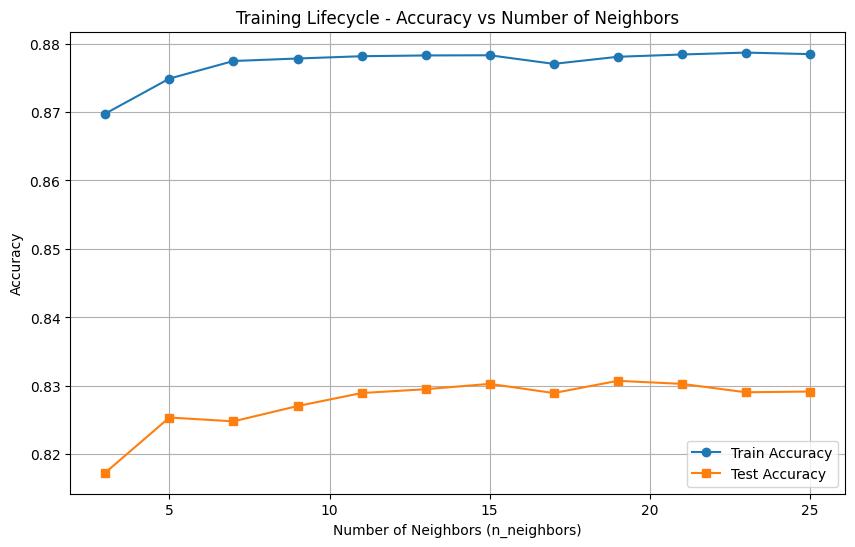

In [8]:
import matplotlib.pyplot as plt

# Load existing study from the database
study = optuna.load_study(
    study_name="knn_diseases_symptoms_dropextremelymore1000withoutSMOTE_SecondAugmentation_study",
    storage="sqlite:///C:/Users/khiew/Downloads/knn.db"
)

# 1. Create model with best parameters
best_params = study.best_trial.params
# ============================
# Simulate Training Lifecycle
# ============================

# We will vary `n_neighbors` to see how accuracy changes
n_neighbors_list = list(range(3, best_params['n_neighbors']+10, 2))  # Varying n_neighbors
train_accuracies = []
test_accuracies = []

for n in n_neighbors_list:
    model = KNeighborsClassifier(
        n_neighbors=n,
        weights=best_params['weights'],
        p=best_params['p']
    )
    
    model.fit(X_train, y_train)

    # Train accuracy
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting the training lifecycle (Accuracy vs n_neighbors)
plt.figure(figsize=(10,6))
plt.plot(n_neighbors_list, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(n_neighbors_list, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('Training Lifecycle - Accuracy vs Number of Neighbors')
plt.legend()
plt.grid(True)
plt.show()

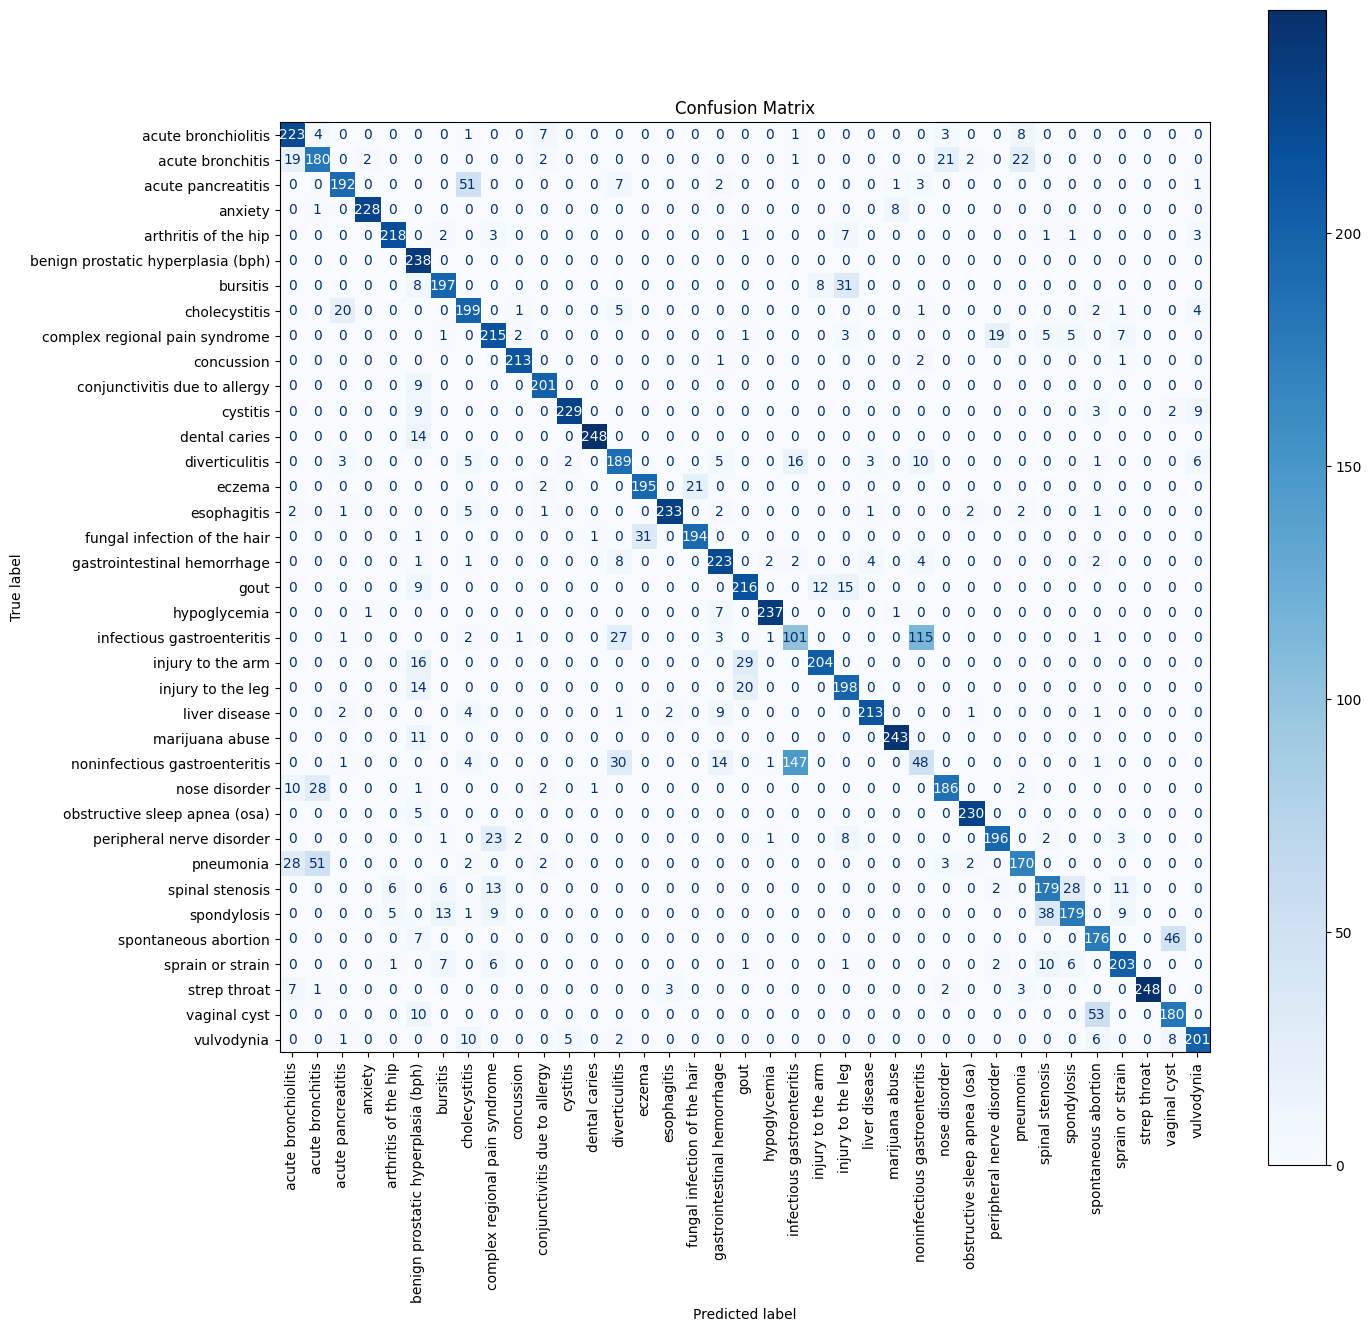

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(15, 15))  # Adjust size as needed
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, xticks_rotation=90, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()
plt.show()